# Lab 2 - Exploring Image Data
- @authors:
    - Truman Barden,
    - Yash Shah,
    - Syed Ameen Zia
- @date: 09/28/25

You are to perform preprocessing and exploratory analysis of a data set: exploring the statistical summaries of the features, visualizing the attributes, and addressing data quality. This report is worth 10% of the final grade. Please upload a report (one per team) with all code used, visualizations, and text in a rendered Jupyter notebook. Any visualizations that cannot be embedded in the notebook, please provide screenshots of the output.

**[Dataset Link](https://www.kaggle.com/datasets/trolukovich/food5k-image-dataset?resource=download)**

In [26]:
## Imports
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from skimage.color import rgb2gray
from skimage.filters import gabor
from skimage.feature import daisy

## Business Understanding

Here

## Data Preparation

Training: (3000, 64, 64, 3) (3000,)
Validation: (1000, 64, 64, 3) (1000,)
Evaluation: (1000, 64, 64, 3) (1000,)
Flattened shape: (3000, 12288)


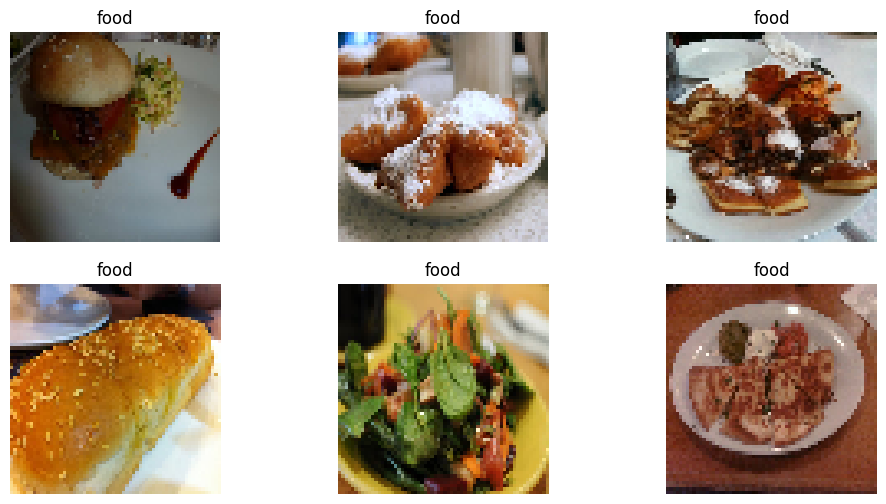

In [27]:
def load_images_from_folder(folder, label, target_size=(64, 64)):
    images, labels = [], []
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = load_img(file_path, target_size=target_size)
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append(label)
    return images, labels

def load_dataset(base_dir, target_size=(64,64)):
    data, labels = [], []
    for category in ["food", "non_food"]:
        folder = os.path.join(base_dir, category)
        imgs, lbls = load_images_from_folder(folder, category, target_size)
        data.extend(imgs)
        labels.extend(lbls)
    return np.array(data), np.array(labels)

# Paths (inside docker container workspace)
train_dir = "datasets/lab2/training"
val_dir   = "datasets/lab2/validation"
eval_dir  = "datasets/lab2/evaluation"

X_train, y_train = load_dataset(train_dir)
X_val, y_val     = load_dataset(val_dir)
X_eval, y_eval   = load_dataset(eval_dir)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Evaluation:", X_eval.shape, y_eval.shape)

# Flatten into 1D feature vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_eval_flat  = X_eval.reshape(X_eval.shape[0], -1)

print("Flattened shape:", X_train_flat.shape)

# Visualize images
def visualize_images(images, labels, n=6):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(2, n//2, i+1)
        plt.imshow(images[i])
        plt.title(labels[i])
        plt.axis("off")
    plt.show()

visualize_images(X_train, y_train)

## Data Reduction

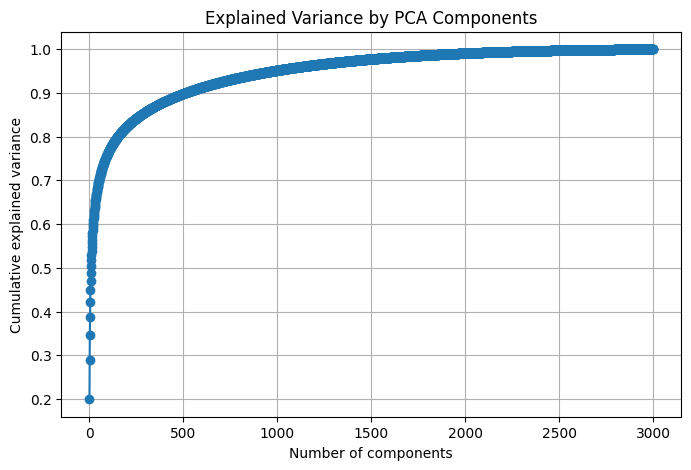

Dimensions for 90% variance (PCA): 510


In [28]:
## PCA

pca = PCA()
pca.fit(X_train_flat)
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_var, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

n_components_90 = np.argmax(explained_var >= 0.90) + 1
print(f"Dimensions for 90% variance (PCA): {n_components_90}")

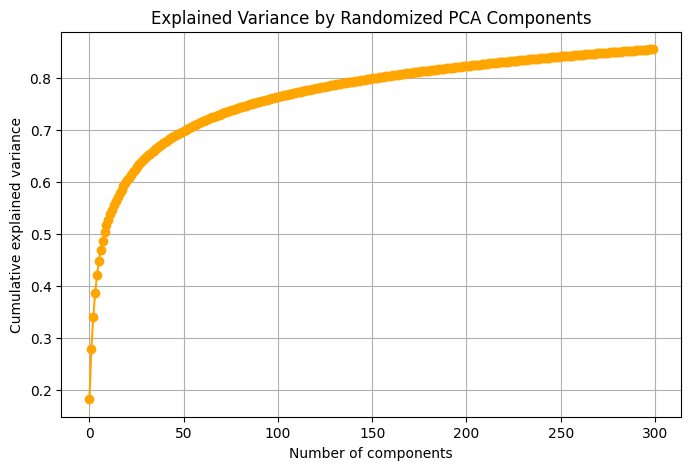

Dimensions for 90% variance (Randomized PCA): 1


In [29]:
## Randomized PCA

rpca = TruncatedSVD(n_components=300, random_state=42)
rpca.fit(X_train_flat)
explained_var_rpca = np.cumsum(rpca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(explained_var_rpca, marker='o', color='orange')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained Variance by Randomized PCA Components")
plt.grid(True)
plt.show()

n_components_90_rpca = np.argmax(explained_var_rpca >= 0.90) + 1
print(f"Dimensions for 90% variance (Randomized PCA): {n_components_90_rpca}")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.09988588..0.715639].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19086927..1.1283469].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17262495..1.0632739].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12291551..1.1508628].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19065288..1.0925002].


Reconstruction MSE (PCA): 0.00816156342625618
Reconstruction MSE (Randomized PCA): 0.06598896533250809


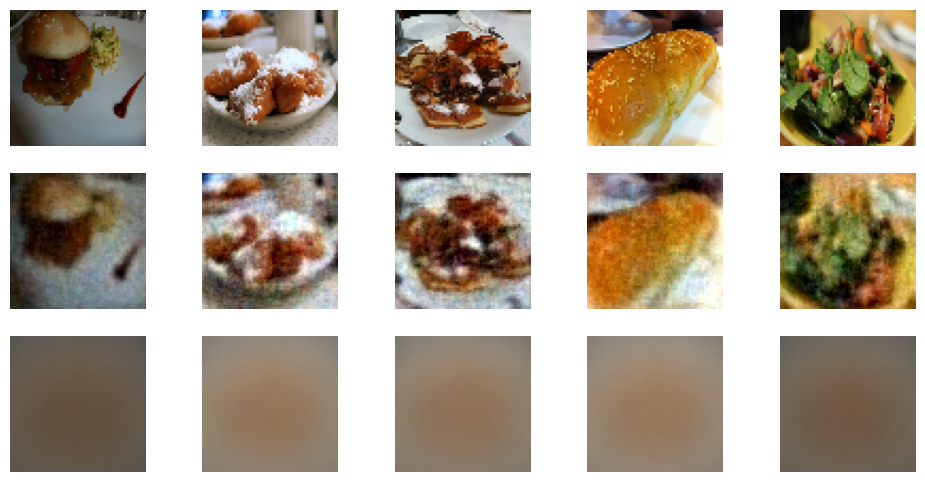

In [30]:
## Quantitative Comparison

subset = X_train_flat  

max_components = min(subset.shape[0], subset.shape[1])
n_pca = min(n_components_90, max_components)
n_rpca = min(n_components_90_rpca, max_components)

# PCA reconstruction
pca_n = PCA(n_components=n_pca)
subset_pca = pca_n.fit_transform(subset)
subset_reconstructed_pca = pca_n.inverse_transform(subset_pca)

# RPCA reconstruction
rpca_n = TruncatedSVD(n_components=n_rpca)
subset_rpca = rpca_n.fit_transform(subset)
subset_reconstructed_rpca = rpca_n.inverse_transform(subset_rpca)

# Reconstruction errors
mse_pca = mean_squared_error(subset, subset_reconstructed_pca)
mse_rpca = mean_squared_error(subset, subset_reconstructed_rpca)
print("Reconstruction MSE (PCA):", mse_pca)
print("Reconstruction MSE (Randomized PCA):", mse_rpca)

# Visual comparison of reconstruction
def visualize_reconstruction(original, rec_pca, rec_rpca, n=5):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(3, n, i+1)
        plt.imshow(original[i].reshape(64,64,3))
        plt.axis("off")
        if i == 0: plt.ylabel("Original")

        plt.subplot(3, n, i+1+n)
        plt.imshow(rec_pca[i].reshape(64,64,3))
        plt.axis("off")
        if i == 0: plt.ylabel("PCA")

        plt.subplot(3, n, i+1+2*n)
        plt.imshow(rec_rpca[i].reshape(64,64,3))
        plt.axis("off")
        if i == 0: plt.ylabel("RPCA")
    plt.show()

visualize_reconstruction(subset, subset_reconstructed_pca, subset_reconstructed_rpca)

In [31]:
## Feature Extraction: Gabor

def extract_gabor_features(images, frequencies=[0.1, 0.2, 0.3]):
    features = []
    for img in images:
        gray = rgb2gray(img)
        feats = []
        for freq in frequencies:
            filt_real, filt_imag = gabor(gray, frequency=freq)
            feats.append(filt_real.mean())
            feats.append(filt_real.var())
        features.append(feats)
    return np.array(features)

X_train_gabor = extract_gabor_features(X_train)
X_val_gabor   = extract_gabor_features(X_val)
X_eval_gabor  = extract_gabor_features(X_eval)

print("Train Gabor shape:", X_train_gabor.shape)
print("Val Gabor shape:", X_val_gabor.shape)
print("Eval Gabor shape:", X_eval_gabor.shape)

Train Gabor shape: (3000, 6)
Val Gabor shape: (1000, 6)
Eval Gabor shape: (1000, 6)


In [32]:
## Feature Extraction: DAISY

def extract_daisy_features(images):
    features = []
    for img in images:
        gray = rgb2gray(img)
        descs = daisy(gray, step=16, radius=15, rings=2, histograms=6, orientations=8)
        features.append(descs.flatten())
    return np.array(features)

# Extract features for all splits
X_train_daisy = extract_daisy_features(X_train)
X_val_daisy   = extract_daisy_features(X_val)
X_eval_daisy  = extract_daisy_features(X_eval)


print("Train DAISY shape:", X_train_daisy.shape)
print("Val DAISY shape:", X_val_daisy.shape)
print("Eval DAISY shape:", X_eval_daisy.shape)

Train DAISY shape: (3000, 936)
Val DAISY shape: (1000, 936)
Eval DAISY shape: (1000, 936)


Combined Test Accuracy (Gabor): 0.657
Combined Test Accuracy (DAISY): 0.7015


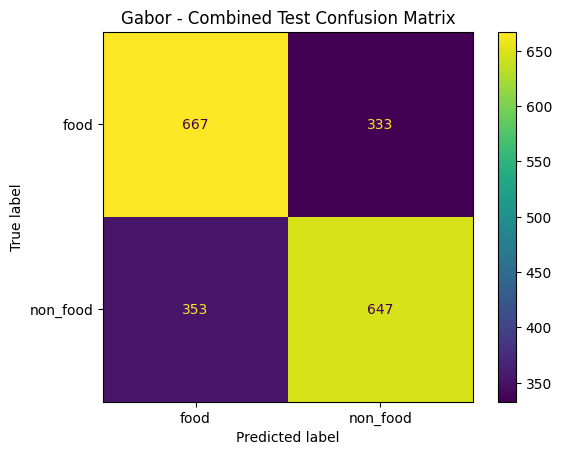

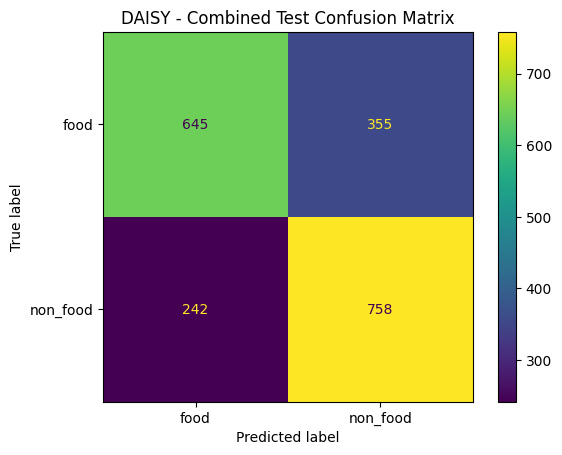

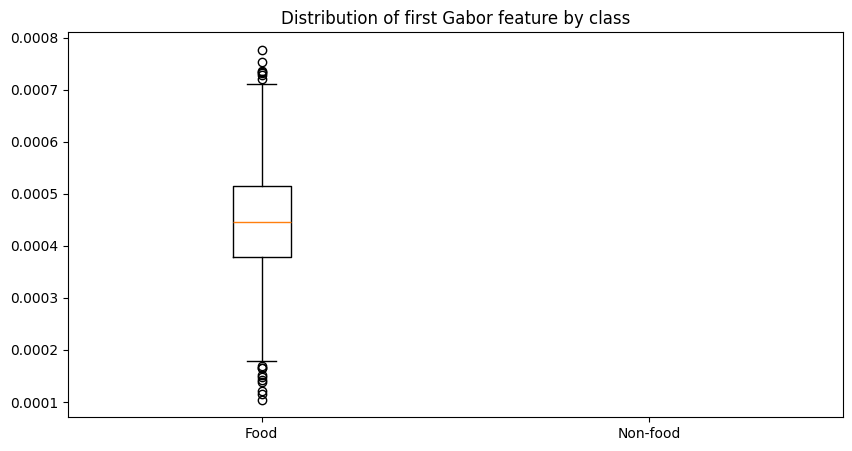

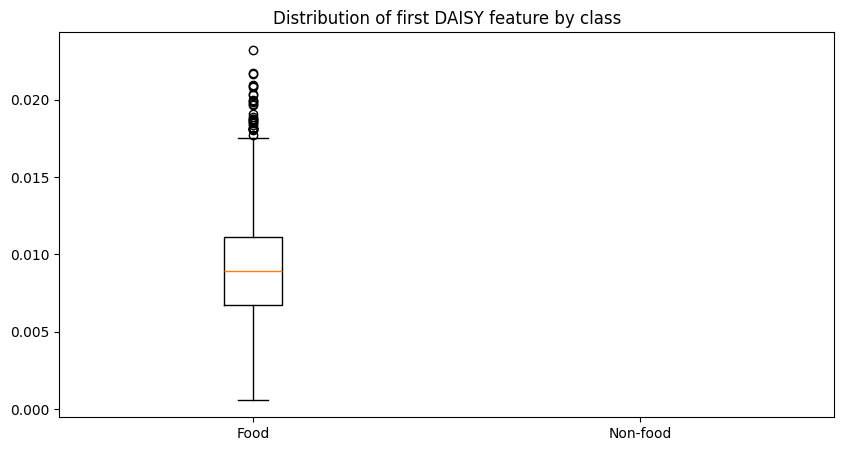

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

# Encode labels consistently across splits
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# Combine validation + evaluation sets
X_test_gabor = np.vstack([X_val_gabor, X_eval_gabor])
X_test_daisy = np.vstack([X_val_daisy, X_eval_daisy])
y_test = np.concatenate([y_val, y_eval])
y_test_enc = le.transform(y_test)

# Train classifiers on training set
knn_gabor = KNeighborsClassifier(n_neighbors=3).fit(X_train_gabor, y_train_enc)
knn_daisy = KNeighborsClassifier(n_neighbors=3).fit(X_train_daisy, y_train_enc)

# Test accuracy (combined val + eval)
test_acc_gabor = knn_gabor.score(X_test_gabor, y_test_enc)
test_acc_daisy = knn_daisy.score(X_test_daisy, y_test_enc)

print("Combined Test Accuracy (Gabor):", test_acc_gabor)
print("Combined Test Accuracy (DAISY):", test_acc_daisy)

# Confusion matrices for combined test set
y_pred_gabor = knn_gabor.predict(X_test_gabor)
y_pred_daisy = knn_daisy.predict(X_test_daisy)

cm_gabor = confusion_matrix(y_test_enc, y_pred_gabor)
cm_daisy = confusion_matrix(y_test_enc, y_pred_daisy)

ConfusionMatrixDisplay(cm_gabor, display_labels=le.classes_).plot()
plt.title("Gabor - Combined Test Confusion Matrix")
plt.show()

ConfusionMatrixDisplay(cm_daisy, display_labels=le.classes_).plot()
plt.title("DAISY - Combined Test Confusion Matrix")
plt.show()

# Boxplots (distributions of first features by class)
plt.figure(figsize=(10,5))
plt.boxplot([X_train_gabor[y_train=="food"][:,0],
             X_train_gabor[y_train=="non-food"][:,0]],
            tick_labels=["Food","Non-food"])
plt.title("Distribution of first Gabor feature by class")
plt.show()

plt.figure(figsize=(10,5))
plt.boxplot([X_train_daisy[y_train=="food"][:,0],
             X_train_daisy[y_train=="non-food"][:,0]],
            tick_labels=["Food","Non-food"])
plt.title("Distribution of first DAISY feature by class")
plt.show()